Visualización de los deslizamientos en China

In [1]:
import pandas as pd
df = pd.read_csv('Global_Landslide_Catalog_Export_rows.csv')
# print(df.head())
print(df['country_name'] == 'China')
df_china = df[df['country_name'] == 'China']
print(df_china.head())
print(df_china.head(10))
print(df_china.shape)
df_china.describe()
df_china['location_description'].unique()
df_china['location_description'].value_counts()

0         True
1        False
2        False
3        False
4        False
         ...  
11028    False
11029    False
11030    False
11031    False
11032    False
Name: country_name, Length: 11033, dtype: bool
             source_name                                        source_link  \
0                    AGU  https://blogs.agu.org/landslideblog/2008/10/14...   
9                    UPI  https://www.upi.com/Top_News/2008/11/05/China-...   
10              BBC News  http://news.bbc.co.uk/2/hi/asia-pacific/771010...   
44            ChinaDaily  http://www.chinadaily.com.cn/china/2009-07/25/...   
444  www.panarmenian.net        http://www.panarmenian.net/eng/news/168583/   

     event_id              event_date  event_time  \
0         684  08/01/2008 12:00:00 AM         NaN   
9         873  11/01/2008 12:00:00 AM         NaN   
10        874  11/01/2008 12:00:00 AM         NaN   
44       1060  07/25/2009 12:00:00 AM         NaN   
444      5357  08/18/2013 12:00:00 AM         Na

location_description
Hunan Province                                             5
Guizhou Province                                           2
Guangdong Province                                         2
Guizhou                                                    2
Sichuan Province                                           2
                                                          ..
Luojiang river, Chengkou county, Chongqing municipality    1
Jiaokou, Xingxian, Lvliang, Shanxi                         1
Mengla                                                     1
Ya'an City                                                 1
Funing County                                              1
Name: count, Length: 409, dtype: int64


La latitud y longitud son coordenadas geográficas que permiten ubicar con precisión cualquier punto en la Tierra mediante grados, minutos y segundos. La latitud mide la distancia norte/sur desde el Ecuador (0° a 90°), mientras que la longitud mide la distancia este/oeste desde el meridiano de Greenwich (0° a 180°). 
Por otro lado la porovincia de Hunan es la que mas deslizamientos registra. Esto nos puede dar una idea de la diferencia de coordenadas dentro de una misma provincia. 

In [4]:
df_china_Hunan = df_china[df_china['location_description'] == 'Hunan Province']
df_china_Hunan.shape

df_china_Hunan['latitude'].value_counts()

latitude
26.443000    1
27.619199    1
28.027000    1
27.670896    1
28.011500    1
Name: count, dtype: int64

Nótese que una diferencia de 1 en latitud puede equivaler a una diferencia de 110 km. 

In [5]:
df_china_Hunan['longitude'].value_counts()

longitude
112.983800    2
111.792000    1
111.456399    1
111.413236    1
Name: count, dtype: int64

In [6]:
df_china_Hunan['location_description'].unique()

array(['Hunan Province'], dtype=object)

Detección de posible inconveniente léxico. Hay descripciones de localizaciones que tienen hunan, pero no unicamente hunan province. 

In [ ]:
# Volvamoa a df_china. Iteramos sobre todas las filas e identificamos si 'Hunan' esta presente en 'location_description'
df_china_Hunan = df_china[df_china['location_description'].str.contains('Hunan', case=False, na=False)]


In [15]:
df_china_Hunan.shape


(23, 31)

In [ ]:
df_china_Hunan['latitude'].value_counts()

latitude
25.329100    2
28.715000    1
26.484500    1
31.292200    1
28.011500    1
28.352700    1
27.670896    1
28.150600    1
28.027000    1
27.619199    1
27.693400    1
29.304600    1
28.215400    1
27.166700    1
30.547500    1
27.696900    1
28.583300    1
28.571600    1
25.790000    1
27.729200    1
26.443000    1
28.529900    1
Name: count, dtype: int64

A continuación vamos a realizar un histograma de menor a mayor según la latitud. 

In [10]:
df_china_Hunan['longitude'].value_counts()

longitude
112.196300    2
112.983800    2
113.557800    1
110.174100    1
103.282700    1
113.005400    1
111.413236    1
113.149000    1
111.456399    1
111.664100    1
110.222500    1
113.587000    1
109.916700    1
114.309300    1
111.993300    1
112.373500    1
109.480700    1
113.020000    1
112.821500    1
111.792000    1
112.317400    1
Name: count, dtype: int64

In [12]:
# vamos a ver el valor mínimo de latitud de df_china_hunan
df_china_Hunan['latitude'].min()
# vamos a ver el valor máximo de latitud de df_china_hunan


25.3291

In [13]:
df_china_Hunan['latitude'].max()

31.2922

In [2]:
# Vale, ahora la idea es construir un histograma con valores de latitud minima y maxima, 25 y 32.5 respectivamente.
import matplotlib.pyplot as plt
plt.hist(df_china_Hunan['latitude'], bins=10, range=(25, 32.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for Hunan Province Landslides')
plt.show()


NameError: name 'df_china_Hunan' is not defined

Bueno, gracias a esto podemos vislumbrar que la mayoría de deslizamientos en este inventario en la provincia de Hunan están entre 27 y 29(aproximadamente, distancias de 22 km entre el minimo de latitud y el maximo de latitud), de latitud, rango el cual representa aproximadamente 15 deslizamientos. 

HAGAMOS LO MISMO CON INDIA

In [3]:

print(df['country_name'] == 'India')
df_India = df[df['country_name'] == 'India']
print(df_India.head())
print(df_India.head(10))
print(df_India.shape)
df_India.describe()
df_India['location_description'].unique()
df_India['location_description'].value_counts()

0        False
1        False
2        False
3        False
4        False
         ...  
11028    False
11029    False
11030    False
11031    False
11032    False
Name: country_name, Length: 11033, dtype: bool
        source_name                                        source_link  \
32        One India  https://www.oneindia.com/2009/07/23/darjeeling...   
34        One India  https://www.oneindia.com/2009/07/23/darjeeling...   
45  Telegraph India  https://www.telegraphindia.com/1090707/jsp/sil...   
59            E-Pao   http://www.e-pao.net/GP.asp?src=28..210810.aug10   
62       ibnlive.in  http://ibnlive.in.com/generalnewsfeed/news/two...   

    event_id              event_date  event_time  \
32      1055  07/22/2009 12:00:00 AM         NaN   
34      1054  07/22/2009 12:00:00 AM         NaN   
45      1061  07/01/2009 05:40:00 AM         NaN   
59      2164  07/29/2010 11:00:00 PM         NaN   
62      3821  07/21/2011 12:00:00 AM         NaN   

                              

location_description
National Highway 31A, Darjeeling Hills                                                                                                                      3
Kurseong                                                                                                                                                    3
Arunachal Pradesh                                                                                                                                           3
Kurseong, Darjeeling, West Bengal                                                                                                                           2
Pithoragarh                                                                                                                                                 2
                                                                                                                                                           ..
Parsad on NH-8                 

In [21]:
df_India_Hills = df_India[df_India['location_description'].str.contains('Darjeeling', case=False, na=False)]
df_India_Hills.shape


(25, 31)

latitude
26.873242    1
26.884057    1
26.882115    1
27.016500    1
26.871200    1
26.899200    1
27.068262    1
27.008700    1
26.883600    1
26.959900    1
26.883300    1
27.117600    1
27.025700    1
27.024598    1
27.036600    1
27.073600    1
27.009500    1
27.040000    1
27.114100    1
26.791400    1
26.997400    1
26.944000    1
27.102700    1
27.009600    1
27.043571    1
Name: count, dtype: int64
26.7914
27.1176


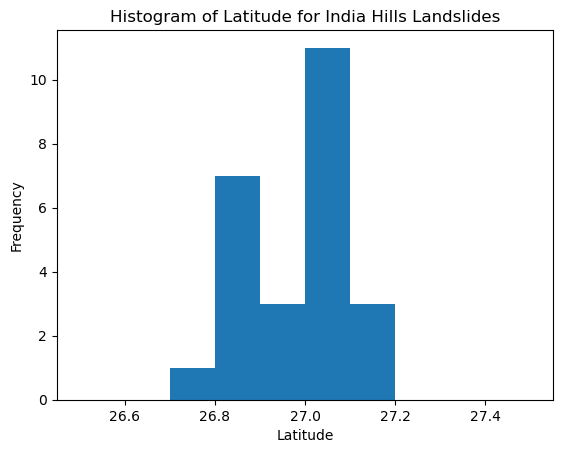

In [27]:
print(df_India_Hills['latitude'].value_counts())
print(df_India_Hills['latitude'].min())
print(df_India_Hills['latitude'].max())
plt.hist(df_India_Hills['latitude'], bins=10, range=(26.5, 27.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for India Hills Landslides')
plt.show()


In [22]:
df_India_Kurseong = df_India[df_India['location_description'].str.contains('Kurseong', case=False, na=False)]
df_India_Kurseong.shape

(14, 31)

In [23]:
df_India_Uttranchal = df_India[df_India['location_description'].str.contains('Uttranchal', case=False, na=False)]
df_India_Uttranchal.shape

(3, 31)

In [24]:
df_India_Chamoli = df_India[df_India['location_description'].str.contains('Chamoli', case=False, na=False)]
df_India_Chamoli.shape

(15, 31)

In [25]:
df_India_Samroli = df_India[df_India['location_description'].str.contains('Samroli', case=False, na=False)]
df_India_Samroli.shape

(5, 31)

POR ÚLTIMO HAGAMOS LO MISMO CON COLOMBIA

In [28]:

print(df['country_name'] == 'Colombia')
df_Colombia = df[df['country_name'] == 'Colombia']
print(df_Colombia.head())
print(df_Colombia.head(10))
print(df_Colombia.shape)
df_Colombia.describe()
print(df_Colombia['location_description'].unique()) 
df_Colombia['location_description'].value_counts()

0        False
1        False
2        False
3        False
4        False
         ...  
11028    False
11029    False
11030    False
11031    False
11032    False
Name: country_name, Length: 11033, dtype: bool
             source_name                                        source_link  \
445              reuters  http://www.reuters.com/article/2011/12/24/us-c...   
763  colombiareports.com  http://colombiareports.com/colombia-news/news/...   
802      insidecostarica  http://www.insidecostarica.com/dailynews/2011/...   
825            El Tiempo  http://www.eltiempo.com/archivo/documento/CMS-...   
965                  UPI  http://www.upi.com/Top_News/2009/04/24/Colombi...   

     event_id              event_date  event_time  \
445      4104  12/23/2011 12:00:00 AM         NaN   
763      3170  03/03/2011 03:00:00 PM         NaN   
802      3353  04/11/2011 12:00:00 AM         NaN   
825      7402  01/29/2016 12:00:00 AM         NaN   
965      1014  04/24/2009 12:00:00 AM         Na

location_description
Dosquebradas, Risaralda                                                            1
Bosa, Bogota                                                                       1
Hacari, North Santander                                                            1
Ceret, Córdoba                                                                     1
Bellavista neighborhood(?), Santa Rosa del Sur municipality, Bolivar department    1
                                                                                  ..
Manizales                                                                          1
road between Bucaramanga and Cucuta                                                1
Avenida Centenario, western part of Manizales city                                 1
Iquira, Huila                                                                      1
just outside Quinchia(villa de los cerros) town, Risaralda dpartment               1
Name: count, Length: 101, dtype: int64

Vale, vamos a hacer una cosa vamos a calcular la frecuencia absoluta de las palabras. 

In [30]:
# Vamos a construir un corpus con las descripciones de la columna 'location_description' de df_Colombia
corpus = df_Colombia["location_description"].tolist()
print(corpus)

['Dosquebradas, Risaralda', 'California village, Sutara valley, NE of Bucaramanga, Santander department', 'San Antonio(?) de Chuza, El Tambo, Narino', 'bus route from Neiva to San Vicente', 'San Juan , Cordoba province', 'rural area of the Samaca municipality, Boyaca department', 'El Cerro, Frontino', 'below Bogota-Medellin highway, Calle Viejo(Old Street)(?), La Gabriela(?), Bello, Medellin, Antioquia state', 'Caldas', 'road between Medellin and  Quibdo, Choco, Colombia', 'near Malaga', 'between Quibdó and Medellín in Chocó Department, Colombia', 'Narino', 'village of San Gerardo, La Cruz, Narino province', 'Calarcá, Quindio', 'Teorama, Norte de Santander', 'La Montera', 'El Poblado, Medellin', 'Caldas, Antioquia', 'San Daniel, Pensilvania municipality, Caldas', 'Cumbal', 'road north of Duitama, Boyaca department', 'La Sierra neighborhood(?), Medellin', 'Cali', 'Juan Bautista Escalabrini, north part of Cucuta', 'Florian, Santander', 'San Francisco area of Putumayo', 'Giradot, Cundinam

In [3]:
from collections import Counter
import string
import re

import pandas as pd
import numpy as np

# Descargamos los recursos necesarios de NLTK si es que no existen previamente en el entorno.
import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

# Módulos necesarios de NLTK que utilizaremos para el preprocesamiento de la información.
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Lematización
# Para que funcione la carga del modelo de lematización este tiene que estar descargado en el entorno primeramente.
# Para ello se puede utilizar alguna de las instrucciones siguientes desde tu entorno Python dependiendo del modelo de lematización que quieras utilizar:
# python -m spacy download es_core_news_sm (modelo pequeño)
# python -m spacy download es_core_news_md (modelo mediano)
import spacy
nlp = spacy.load("es_core_news_sm")
# nlp = spacy.load("es_core_news_md")
def preprocesar_documento(documento):
    """
    Función para preprocesar un documento individual
    
    Args:
        documento (str): Texto del documento a preprocesar
    
    Returns:
        list: Lista de tokens normalizados para el texto a preprocesar.
    """
    # Convertir a minúsculas
    documento = documento.lower()
    
    # Eliminar signos de puntuación usando expresiones regulares
    # documento = re.sub(r'[^\w\s]', '', documento)
    
    # Tokenizar usando NLTK
    tokens = word_tokenize(documento, language='spanish')

    # Eliminación de puntuación y stopwords
    stop_words = set(stopwords.words("spanish"))
    tokens_limpios = [t for t in tokens if t not in string.punctuation and t not in stop_words]
    
    # Filtrar tokens que no sean alfabéticos (eliminar números)
    tokens_filtrados = [token for token in tokens_limpios if token.isalpha()]


    
    return tokens_filtrados



In [43]:

train_documentos_procesados = []
for doc in df_Colombia['location_description']:
    tokens = preprocesar_documento(doc)

    train_documentos_procesados.append(" ".join(tokens))


# Número de documentos de entrenamiento procesados
print(f"Número de documentos de entrenamiento procesados: {len(train_documentos_procesados)}")
print(f"Documentos de entrenamiento procesados: {train_documentos_procesados[:20]}...")

Número de documentos de entrenamiento procesados: 101
Documentos de entrenamiento procesados: ['dosquebradas risaralda', 'california village sutara valley ne of bucaramanga santander department', 'san antonio chuza tambo narino', 'bus route from neiva to san vicente', 'san juan cordoba province', 'rural area of the samaca municipality boyaca department', 'cerro frontino', 'below highway calle viejo old street gabriela bello medellin antioquia state', 'caldas', 'road between medellin and quibdo choco colombia', 'near malaga', 'between quibdó and medellín in chocó department colombia', 'narino', 'village of san gerardo cruz narino province', 'calarcá quindio', 'teorama norte santander', 'montera', 'poblado medellin', 'caldas antioquia', 'san daniel pensilvania municipality caldas']...


In [4]:
# Módulos necesarios de la librería Scikit-Learn que vamos a utilizar para a construcción del modelo TF-IDF.
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

In [36]:
# Vectorizamos los documentos de test usando TF-IDF
# Crea el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer (
    stop_words=None, 
    ngram_range= (1,1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features= None
)


X_train_tfidf_full = tfidf_vectorizer.fit_transform(raw_documents=train_documentos_procesados)

# Entrenamos el clasificador NB usando los datos vectorizados por TF-IDF
clf_tfidf_full = MultinomialNB (
    alpha= 1.0,
    force_alpha= True,
    fit_prior= True, 
    class_prior= None,
)
clf_tfidf_full.fit(X_train_tfidf_full, df_Colombia['location_description'])

# Mostramos algunos aspectos del modelo entrenado.

print("Clases del modelo NB por TF-IDF entrenado:", clf_tfidf_full.classes_)

# Muestra top frecuencias del modelo TF-IDF
feature_counts = np.asarray(X_train_tfidf_full.sum(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_freq = list(zip(feature_names, feature_counts)) # Lista de tuplas (palabra, frecuencia)
feature_freq.sort(key=lambda x: x[1], reverse=True)
print("Top 10 palabras más frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[:10]:
    print(f"{word}: {freq}")
print("Top 10 palabras menos frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[-10:]:   
    print(f"{word}: {freq}")

Clases del modelo NB por TF-IDF entrenado: [' Antioquia '
 '(image shows location on hillside between El Codito on San Antonio), El Codito, Bogota'
 'Alto de La Linea highway, Cansaperros, between Ibague and Armenia'
 'Antioquia, Medellin'
 'Avenida Centenario, western part of Manizales city'
 'Bellavista neighborhood(?), Santa Rosa del Sur municipality, Bolivar department'
 'Bendiciones, near Buenaventura, Columbia' 'Bolivar province'
 'Bolivar, Cauca' 'Bosa, Bogota' 'Bucaramanga, Santander'
 'Cajamarca, Quindio' 'Calarcá, Quindio' 'Caldas' 'Caldas, Antioquia'
 'Cali'
 'California village, Sutara valley, NE of Bucaramanga, Santander department'
 'Carmen de Atrato, Choco, Bogata'
 'Cauca Rivera(Cauca river), Antioquia department' 'Ceret, Córdoba'
 'Cervantes, Manizales, Caldas' 'Ciudad Bolivar area Bogota'
 "Colombia's northwestern Antioquia province, town of Guatupe" 'Cumbal'
 'Córdoba department' 'Dosquebradas, Risaralda'
 'El Aguacate(?), Marquetalia municipality, Caldas' 'El Cerro,

Gracias a esto hemos visto que Antioquia es la palabra más frecuente

In [37]:
df_Colombia_Antioquia = df_Colombia[df_Colombia['location_description'].str.contains('Antioquia', case=False, na=False)]
df_Colombia_Antioquia.shape

(11, 31)

latitude
6.3236    1
6.0800    1
7.1600    1
6.3704    1
5.0255    1
6.7060    1
6.2379    1
6.2433    1
6.4680    1
6.2336    1
7.6167    1
Name: count, dtype: int64
5.0255
7.6167


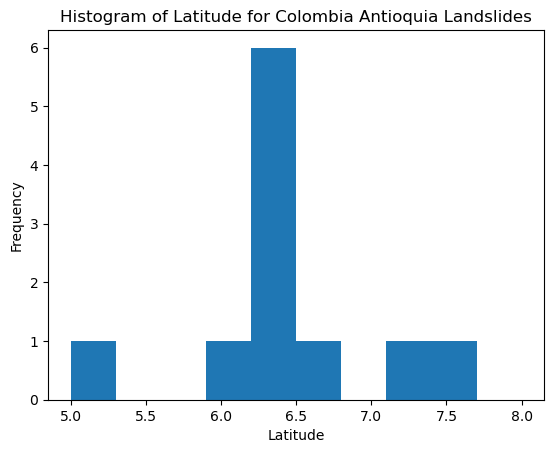

In [39]:
print(df_Colombia_Antioquia['latitude'].value_counts())
print(df_Colombia_Antioquia['latitude'].min())
print(df_Colombia_Antioquia['latitude'].max())
plt.hist(df_Colombia_Antioquia['latitude'], bins=10, range=(5, 8))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for Colombia Antioquia Landslides')
plt.show()

En vista de la conveniencia de encontrar el termino más frecuente en la variable, location description, se propone hacerlo también para China y para India. 

In [5]:
print(df_china['location_description'].unique())
df_china.shape


['Sigou Village, Loufan County, Shanxi Province'
 'Lincang City, Yunnan, Yunnan-Tibet No. 214 highway.' 'Kunming, Yunnan'
 'Wenchuan County, Sichuan' 'Guangxi City Of Wuzhou'
 "Longchang Town,\xa0Kaili\xa0City, Southwest China'S Guizhou Province"
 'Yingping village, Daoping town, Fuquan city'
 ' Maojiazu(?) subvillage, Guanshan village(?), near Yunshan(Dayunshan) National Forest Park, Zhanqiao township, Linxiang district, Yueyang city, Hunan'
 'National Highway 318, Zham, Nyalam County, Tibet'
 'Minhou county, Fujian province, China' 'Zengjiapingzi Stop' 'Shenzhen'
 'Xinhua,Sichuan' 'Chagou Village In\xa0Shilou County In Shanxi Province'
 'Tengchong' 'Suichuan County' 'Taoshi, Shanxi'
 'northern bank of the Daning River in Chongqing   Read more: http://www.cctv-america.com/2015/06/25/13-boats-capsized-after-chongqing-landslide#ixzz3eBf7QOfx  Watch us live anywhere at http://www.cctvamericalive.com  Follow us: @cctv_america on Twitter | CCTVAmerica on Facebook'
 'Jiangxi Province'
 'Hua

(426, 31)

Hemos identificado el error. Hay un fucking nan

In [6]:
# Vamos a eliminar una fila si contiene nan en la columna 'location_description'
df_china = df_china.dropna(subset=['location_description'])

In [7]:
df_china.shape

(422, 31)

In [8]:

train_documentos_procesados_c = []
for doc in df_china['location_description']:
    print(doc)
    tokens = preprocesar_documento(doc)

    train_documentos_procesados_c.append(" ".join(tokens))

# Número de documentos de entrenamiento procesados
print(f"Número de documentos de entrenamiento procesados: {len(train_documentos_procesados_c)}")
print(f"Documentos de entrenamiento procesados: {train_documentos_procesados_c[:3]}...")

Sigou Village, Loufan County, Shanxi Province
Lincang City, Yunnan, Yunnan-Tibet No. 214 highway.
Kunming, Yunnan
Wenchuan County, Sichuan
Guangxi City Of Wuzhou
Longchang Town, Kaili City, Southwest China'S Guizhou Province
Yingping village, Daoping town, Fuquan city
 Maojiazu(?) subvillage, Guanshan village(?), near Yunshan(Dayunshan) National Forest Park, Zhanqiao township, Linxiang district, Yueyang city, Hunan
National Highway 318, Zham, Nyalam County, Tibet
Minhou county, Fujian province, China
Zengjiapingzi Stop
Shenzhen
Xinhua,Sichuan
Chagou Village In Shilou County In Shanxi Province
Tengchong
Suichuan County
Taoshi, Shanxi
northern bank of the Daning River in Chongqing   Read more: http://www.cctv-america.com/2015/06/25/13-boats-capsized-after-chongqing-landslide#ixzz3eBf7QOfx  Watch us live anywhere at http://www.cctvamericalive.com  Follow us: @cctv_america on Twitter | CCTVAmerica on Facebook
Jiangxi Province
Huaiji County in the city of Zhaoqing, Guangdong Province
Xiangx

In [9]:
# Vectorizamos los documentos de test usando TF-IDF
# Crea el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer (
    stop_words=None, 
    ngram_range= (1,1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features= None
)


X_train_tfidf_full = tfidf_vectorizer.fit_transform(raw_documents=train_documentos_procesados_c)

# Entrenamos el clasificador NB usando los datos vectorizados por TF-IDF
clf_tfidf_full = MultinomialNB (
    alpha= 1.0,
    force_alpha= True,
    fit_prior= True, 
    class_prior= None,
)
clf_tfidf_full.fit(X_train_tfidf_full, df_china['location_description'])

# Mostramos algunos aspectos del modelo entrenado.

print("Clases del modelo NB por TF-IDF entrenado:", clf_tfidf_full.classes_)

# Muestra top frecuencias del modelo TF-IDF
feature_counts = np.asarray(X_train_tfidf_full.sum(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_freq = list(zip(feature_names, feature_counts)) # Lista de tuplas (palabra, frecuencia)
feature_freq.sort(key=lambda x: x[1], reverse=True)
print("Top 10 palabras más frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[:10]:
    print(f"{word}: {freq}")
print("Top 10 palabras menos frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[-10:]:   
    print(f"{word}: {freq}")

Clases del modelo NB por TF-IDF entrenado: [' Maojiazu(?) subvillage, Guanshan village(?), near Yunshan(Dayunshan) National Forest Park, Zhanqiao township, Linxiang district, Yueyang city, Hunan'
 '2 km from the Zham Port, on China-Nepal Highway, Tibet'
 '4 provincial-level regions (Chongqing, Sichuan, Guizhou, and Yunnan); also in Bingzhonglou county'
 'A highway in Yunnan Province, Fugong County, Nujiang Lisu Autonomous Prefecture'
 'Anhui' 'Ankang' 'Ankang City' 'Ankang city, Shaanzi Province'
 'Badong county, Hubei province'
 'Baihe County of Ankang City, Shaanxi Province'
 'Baijian Town, Jixian county' 'Baimu River in Ya’an City'
 'Baliu\xa0Township, Mojiang Hani Autonomous County'
 'Banpo Village, Leibo County, Sichuan Province ('
 "Bao'an District, Shenzhen, Guangdong Province" 'Beichuan County'
 "Beijing-Kunming expressway, Ya'an, Sichuan province" 'Bijie, Guizhou'
 'Bijie, Guizhou Province' 'Bobai,Guangxi Zhuang'
 'Bomi County, eastern Tibet, of the Sichuan-Tibet highway'
 "Bo

Pues mira nos hemos llevado una sorpresa. En vez de ser Hunan, Yunnan y Sichuan son bastante más frecuentes. 

(63, 31)
latitude
29.9816    2
31.4830    1
32.4879    1
27.8235    1
30.4297    1
          ..
31.5751    1
29.6491    1
30.6887    1
28.7000    1
30.9896    1
Name: count, Length: 62, dtype: int64
23.37
34.0982


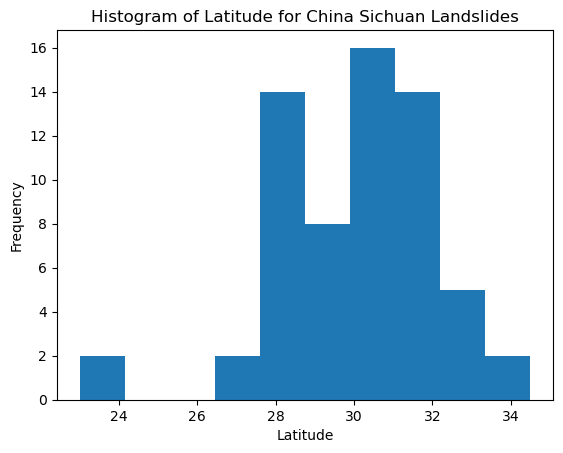

In [56]:
df_China_Sichuan = df_china[df_china['location_description'].str.contains('Sichuan', case=False, na=False)]
print(df_China_Sichuan.shape)
print(df_China_Sichuan['latitude'].value_counts())
print(df_China_Sichuan['latitude'].min())
print(df_China_Sichuan['latitude'].max())
plt.hist(df_China_Sichuan['latitude'], bins=10, range=(23, 34.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for China Sichuan Landslides')
plt.show()

El resultado es que hemos identificado 63 deslizamientos. Aunque es verdad que con un rango de latitud mucho mayor. Pero aun así, salimos ganando!

HAGAMOS LO MISMO CON INDIA

In [57]:
df_India.shape

(1265, 31)

In [59]:
df_India = df_India.dropna(subset=['location_description'])
df_India.shape

(1254, 31)

In [60]:
train_documentos_procesados_I = []
for doc in df_India['location_description']:
    print(doc)
    tokens = preprocesar_documento(doc)

    train_documentos_procesados_I.append(" ".join(tokens))

# Número de documentos de entrenamiento procesados
print(f"Número de documentos de entrenamiento procesados: {len(train_documentos_procesados_I)}")
print(f"Documentos de entrenamiento procesados: {train_documentos_procesados_I[:3]}...")

Kerseong, West Bengal 
Gayabari,  West Bengal 
4th Mile, Lower Mangshila in North Sikkim
Chingai-Kuingai(Quingai) route (16 kms), Chingai subdivision, Ukhrul district, Manipur
Kumaon, Uttarakhand
Doba
National Highway leading to Gangotri, from Dehradun
Gangotri
Kedarnath
Yamunotri
Chamoli , Uttarakhand
Jatog and Kaithlighat railway stations, Kaithleeghat, Himachal Pradesh
North Skkimm Hwy between, Chungthang and Mangan, North Skimm (9 landslides)
 Chungthang and Pegong. Houses, between Rangma and Chungthang 
Rishikesh-Joshimath-Mana Road, Uttarakhand
Dharasu-Gangotri Road, Uttarakhand
Pithoragarh-Ghatiabgarh Road, Uttarakhand
Thenpara, Kerala-Tamil Nadu Inter-State Highway, Nadukani Ghat Road Connecting Nilambur With Gudallur In Tamilnadu
Jaram, Kerala-Tamil Nadu Inter-State Highway, Nadukani Ghat Road Connecting Nilambur With Gudallur In Tamilnadu
National Highway 29 Between Patkai Bridge And Kukidolong, Nagaland
National Highway 2 Near Meriema Village, 10 Km Away From Kohima
Frasthar

In [63]:
# Vectorizamos los documentos de test usando TF-IDF
# Crea el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer (
    stop_words=None, 
    ngram_range= (1,1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features= None
)


X_train_tfidf_full = tfidf_vectorizer.fit_transform(raw_documents=train_documentos_procesados_I)

# Entrenamos el clasificador NB usando los datos vectorizados por TF-IDF
clf_tfidf_full = MultinomialNB (
    alpha= 1.0,
    force_alpha= True,
    fit_prior= True, 
    class_prior= None,
)
clf_tfidf_full.fit(X_train_tfidf_full, df_India['location_description'])

# Mostramos algunos aspectos del modelo entrenado.

print("Clases del modelo NB por TF-IDF entrenado:", clf_tfidf_full.classes_)

# Muestra top frecuencias del modelo TF-IDF
feature_counts = np.asarray(X_train_tfidf_full.sum(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_freq = list(zip(feature_names, feature_counts)) # Lista de tuplas (palabra, frecuencia)
feature_freq.sort(key=lambda x: x[1], reverse=True)
print("Top 10 palabras más frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[:20]:
    print(f"{word}: {freq}")
print("Top 10 palabras menos frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[-10:]:   
    print(f"{word}: {freq}")

Clases del modelo NB por TF-IDF entrenado: [' Botsa  and Chiechama' ' Ramban district of Jammu and Kashmir'
 '(Okai Tea Garden) Mirik, Darjeeling, West Bengal' ...
 '\xa0Jammu-Srinagar' '\xa0Varai, Maharashtra'
 '\xa0between Harangajao and Mailongdisa, Assa,']
Top 10 palabras más frecuentes (modelo TF-IDF)
------------------------------
highway: 52.723118194729814
district: 48.12638172177009
pradesh: 40.78366680298196
uttarakhand: 40.55525438398726
road: 39.76598602699016
and: 39.74166538233415
near: 38.64054109686874
in: 33.613661381285695
village: 30.160140057681282
himachal: 29.722349936428234
national: 27.515320252879295
india: 25.650843598417868
of: 25.025707128603425
kashmir: 23.739638935201025
between: 21.802026509103985
nagaland: 21.309130145436125
jammu: 19.726290216272833
ramban: 18.156069045432258
area: 17.78594297549647
manipur: 17.074378308672582
Top 10 palabras menos frecuentes (modelo TF-IDF)
------------------------------
center: 0.23781805658889527
narayan: 0.237818056

Nos volvemos a sorprender porque Kurseong no está en las palabras más frecuentes. La provincia más frecuente es uttarakhand. Aunque es un estado. Himachal es otro estado. Aunque no me había dado cuenta pero Sichuan(la que se ha utilizado en China), lo llaman provincia pero es enorme. Así pues, procedamos con uttarakhand.

(109, 31)
latitude
30.4043    2
30.8928    2
30.5345    2
30.7351    1
29.3576    1
          ..
30.7332    1
30.9660    1
29.8410    1
29.5800    1
30.3299    1
Name: count, Length: 106, dtype: int64
28.8665
31.0826


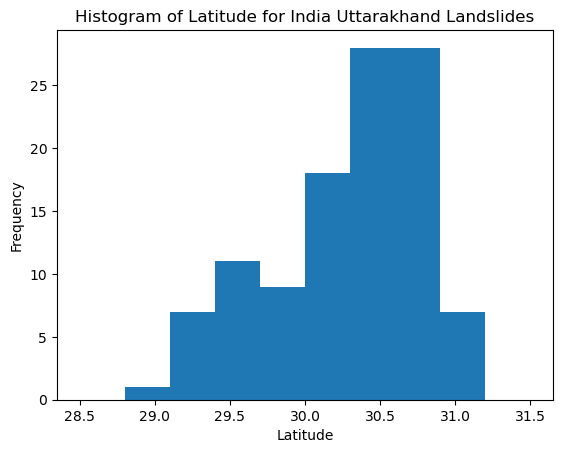

In [6]:
df_india_uttarakhand = df_India[df_India['location_description'].str.contains('Uttarakhand', case=False, na=False)]
print(df_india_uttarakhand.shape)
print(df_india_uttarakhand['latitude'].value_counts())
print(df_india_uttarakhand['latitude'].min())
print(df_india_uttarakhand['latitude'].max())
plt.hist(df_india_uttarakhand['latitude'], bins=10, range=(28.5, 31.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for India Uttarakhand Landslides')
plt.show()

Y de nuevo hemos logrado recoger muchísimos más deslizamientos en menor territorio. 

Sería conveniente también ver la diferencia de longitud

In [67]:
# Ahora vamos a ver la longitud minima y maxima de cada región seleccionada de cada pais. Empecemos con China Sichuan.
df_china_sichuan = df_china[df_china['location_description'].str.contains('Sichuan', case=False, na=False)]
print(df_china_sichuan.shape)
print(df_china_sichuan['longitude'].value_counts())
print(df_china_sichuan['longitude'].min())
print(df_china_sichuan['longitude'].max())

(63, 31)
longitude
103.5868    1
105.8453    1
101.8873    1
97.1598     1
102.8154    1
           ..
103.7281    1
94.3615     1
103.9291    1
104.5167    1
103.6405    1
Name: count, Length: 63, dtype: int64
94.3615
116.7035


Según Gemini, en 20 grados de longitud a la altura de Sichuan podría haber una diferencia 2000 km. :(

In [7]:
df_india_uttarakhand = df_India[df_India['location_description'].str.contains('Uttarakhand', case=False, na=False)]
print(df_india_uttarakhand.shape)
print(df_india_uttarakhand['longitude'].value_counts())
print(df_india_uttarakhand['longitude'].min())
print(df_india_uttarakhand['longitude'].max())

(109, 31)
longitude
78.4800    2
79.0853    2
79.6367    1
79.0666    1
79.5519    1
          ..
78.7756    1
78.4401    1
78.4151    1
79.7758    1
79.3206    1
Name: count, Length: 107, dtype: int64
77.0666
80.8576


Según Gemini, en 4 grados de longitud a la altura de uttarakhand podría haber una diferencia 385 km. :)

In [69]:
df_Colombia_Antioquia = df_Colombia[df_Colombia['location_description'].str.contains('Antioquia', case=False, na=False)]
print(df_Colombia_Antioquia.shape)
print(df_Colombia_Antioquia['longitude'].value_counts())
print(df_Colombia_Antioquia['longitude'].min())
print(df_Colombia_Antioquia['longitude'].max())

(11, 31)
longitude
-75.5455    1
-75.6390    1
-75.5200    1
-75.4408    1
-75.5236    1
-75.9917    1
-75.5283    1
-75.5767    1
-74.9411    1
-75.1619    1
-75.3337    1
Name: count, dtype: int64
-75.9917
-74.9411


Según Gemini, en 1 grados de longitud a la altura de Antioquia podría haber una diferencia 111 km. :)

Vale, ahora vamos a ver que polígono forma las diferentes regiones. Lo cual, es la única forma de determinar verdaderamente si las zonas son manejables. 

CHINA

(63, 31)
latitude
29.9816    2
31.4830    1
32.4879    1
27.8235    1
30.4297    1
          ..
31.5751    1
29.6491    1
30.6887    1
28.7000    1
30.9896    1
Name: count, Length: 62, dtype: int64
23.37
34.0982


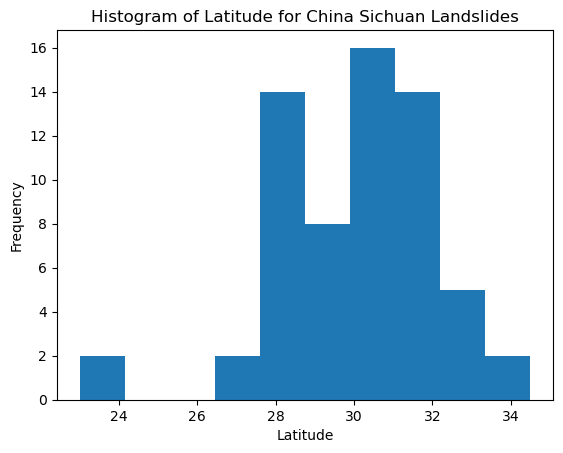

In [70]:
df_China_Sichuan = df_china[df_china['location_description'].str.contains('Sichuan', case=False, na=False)]
print(df_China_Sichuan.shape)
print(df_China_Sichuan['latitude'].value_counts())
print(df_China_Sichuan['latitude'].min())
print(df_China_Sichuan['latitude'].max())
plt.hist(df_China_Sichuan['latitude'], bins=10, range=(23, 34.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for China Sichuan Landslides')
plt.show()

Vamos a reducir el rango a (29.5, 32.5)

In [108]:
# dentro del dataset de df china sichuan, vamos a descartar los eventos que tengan latitud < 29.5, > 32.5
df_China_Sichuan_filtered = df_China_Sichuan[(df_China_Sichuan['latitude'] >= 29.5) & (df_China_Sichuan['latitude'] <= 32.5)]
df_China_Sichuan_filtered.shape

(36, 31)

Bueno no está mal del todo, 36 eventos. Realicemos un hsitograma. Y aprovechamos para ver la longitud(recemos)

94.3615
106.6332


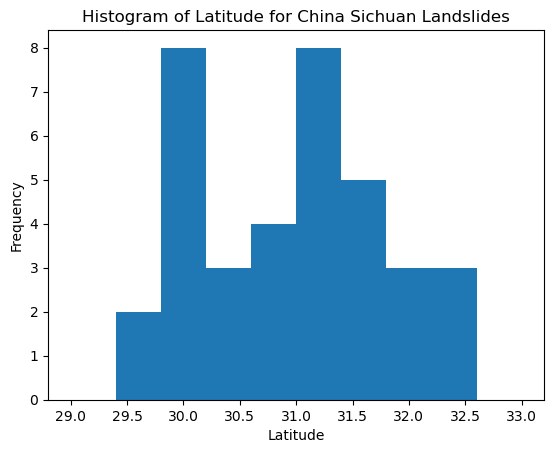

In [88]:
print(df_China_Sichuan_filtered['longitude'].min())
print(df_China_Sichuan_filtered['longitude'].max())
plt.hist(df_China_Sichuan_filtered['latitude'], bins=10, range=(29, 33))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for China Sichuan Landslides')
plt.show()

La diferencia de longitudes sigue siendo significativa. Hagamos un histograma para longitudes.

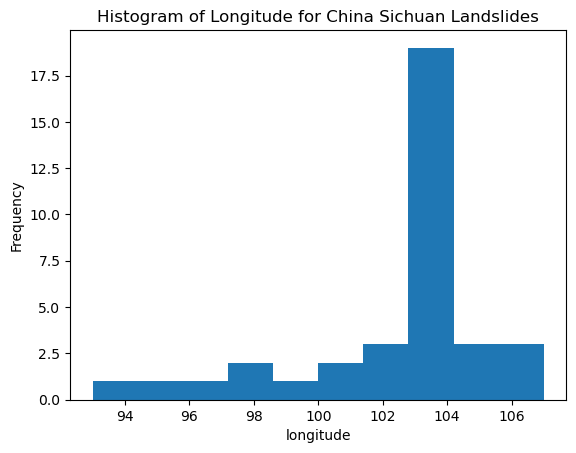

In [89]:
plt.hist(df_China_Sichuan_filtered['longitude'], bins=10, range=(93, 107))
plt.xlabel('longitude')
plt.ylabel('Frequency')
plt.title('Histogram of Longitude for China Sichuan Landslides')
plt.show()

Bueno consultado con Gemini, una diferencia de 4 en longitud en Sichuan podría equivaler a 386 km. Es probablemente manejable. Si efectivamente estoy pensando en coger latitudes de (102, 106)

In [90]:
# Reduzcamos el dataset a eventos cuyas longitudes estén comprendidas entre 102 y 106
df_China_Sichuan_filtered = df_China_Sichuan_filtered[(df_China_Sichuan_filtered['longitude'] >= 102) & (df_China_Sichuan_filtered['longitude'] <= 106)]
df_China_Sichuan_filtered.shape

(24, 31)

Vale ahora vamos a ver cual es la esquina inferior izquierda: menor latitud, y de esos menor longitud. 

In [91]:
# Vale ahora vamos a ver cual es la esquina inferior izquierda: menor latitud, y de esos menor longitud. Y la esquina superior derecha: mayor latitud, y de esos mayor longitud.
min_lat = df_China_Sichuan_filtered['latitude'].min()
min_lon = df_China_Sichuan_filtered[df_China_Sichuan_filtered['latitude'] == min_lat]['longitude'].min()
max_lat = df_China_Sichuan_filtered['latitude'].max()
max_lon = df_China_Sichuan_filtered[df_China_Sichuan_filtered['latitude'] == max_lat]['longitude'].max()
print(f"Esquina inferior izquierda: lat={min_lat}, lon={min_lon}")
print(f"Esquina superior derecha: lat={max_lat}, lon={max_lon}")

Esquina inferior izquierda: lat=29.9816, lon=103.0129
Esquina superior derecha: lat=32.4879, lon=105.8453


Repitamos el proceso para India y Colombia

INDIA

(109, 31)
latitude
30.4043    2
30.8928    2
30.5345    2
30.7351    1
29.3576    1
          ..
30.7332    1
30.9660    1
29.8410    1
29.5800    1
30.3299    1
Name: count, Length: 106, dtype: int64
28.8665
31.0826


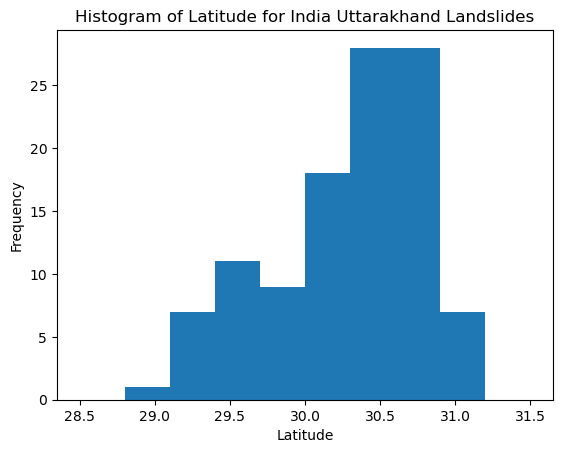

In [8]:
df_india_uttarakhand = df_India[df_India['location_description'].str.contains('Uttarakhand', case=False, na=False)]
print(df_india_uttarakhand.shape)
print(df_india_uttarakhand['latitude'].value_counts())
print(df_india_uttarakhand['latitude'].min())
print(df_india_uttarakhand['latitude'].max())
plt.hist(df_india_uttarakhand['latitude'], bins=10, range=(28.5, 31.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for India Uttarakhand Landslides')
plt.show()

In [9]:
# Cogemos eventos que estén dentro del rango de latitud: (29, 31)
df_india_uttarakhand_filtered = df_india_uttarakhand[(df_india_uttarakhand['latitude'] >= 29) & (df_india_uttarakhand['latitude'] <= 31)]
print(df_india_uttarakhand_filtered.shape)
# Ahora vemos los limites de longitud de este nuevo dataset filtrado
print(df_india_uttarakhand_filtered['longitude'].min())
print(df_india_uttarakhand_filtered['longitude'].max())

(106, 31)
77.0666
80.8576


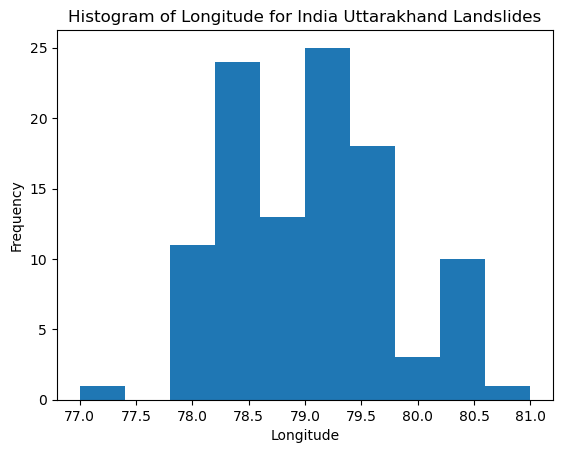

In [10]:
# Construyamos un histograma de longitudes para este nuevo dataset filtrado
plt.hist(df_india_uttarakhand_filtered['longitude'], bins=10, range=(77, 81))
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.title('Histogram of Longitude for India Uttarakhand Landslides')
plt.show()

In [11]:
# Reduzcamos el dataset a eventos cuyas longitudes estén comprendidas entre 78 y 80.5
df_india_uttarakhand_filtered = df_india_uttarakhand_filtered[(df_india_uttarakhand_filtered['longitude'] >= 78) & (df_india_uttarakhand_filtered['longitude'] <= 80.5)]
print(df_india_uttarakhand_filtered.shape)

(103, 31)


In [12]:
# Ahora comprobamos esquina inferior izquierda: menor latitud, y de esos menor longitud. Y la esquina superior derecha: mayor latitud, y de esos mayor longitud.
min_lat = df_india_uttarakhand_filtered['latitude'].min()   
min_lon = df_india_uttarakhand_filtered[df_india_uttarakhand_filtered['latitude'] == min_lat]['longitude'].min()
max_lat = df_india_uttarakhand_filtered['latitude'].max()
max_lon = df_india_uttarakhand_filtered[df_india_uttarakhand_filtered['latitude'] == max_lat]['longitude'].max()
print(f"Esquina inferior izquierda: lat={min_lat}, lon={min_lon}")
print(f"Esquina superior derecha: lat={max_lat}, lon={max_lon}")

Esquina inferior izquierda: lat=29.1585, lon=79.1464
Esquina superior derecha: lat=30.9753, lon=78.4375


In [13]:
# A ver la longitud de la esquina inferior derecha es mayor a la longitud de la esquin asuperior derecha. Eso significa que el polígono que hay que obtener es 
# esquina inferior derecha -- esquia superior izquierda, es decir: inf_dcha va a ser primero max longitud y luego minima latitud, y sup_izq va a ser minima longitud y luego max latitud
inf_dcha_lon = df_india_uttarakhand_filtered['longitude'].max()   
inf_dcha_lat = df_india_uttarakhand_filtered[df_india_uttarakhand_filtered['longitude'] == inf_dcha_lon]['latitude'].min()
sup_izq_lon = df_india_uttarakhand_filtered['longitude'].min()
sup_izq_lat = df_india_uttarakhand_filtered[df_india_uttarakhand_filtered['longitude'] == sup_izq_lon]['latitude'].max()
print(f"Esquina inferior derecha: lat={inf_dcha_lat}, lon={inf_dcha_lon}")
print(f"Esquina superior izquierda: lat={sup_izq_lat}, lon={sup_izq_lon}")

Esquina inferior derecha: lat=29.7986, lon=80.417
Esquina superior izquierda: lat=30.3069, lon=78.0169


Bueno, un polígono un tanto raro

COLOMBIA

latitude
6.3236    1
6.0800    1
7.1600    1
6.3704    1
5.0255    1
6.7060    1
6.2379    1
6.2433    1
6.4680    1
6.2336    1
7.6167    1
Name: count, dtype: int64
5.0255
7.6167


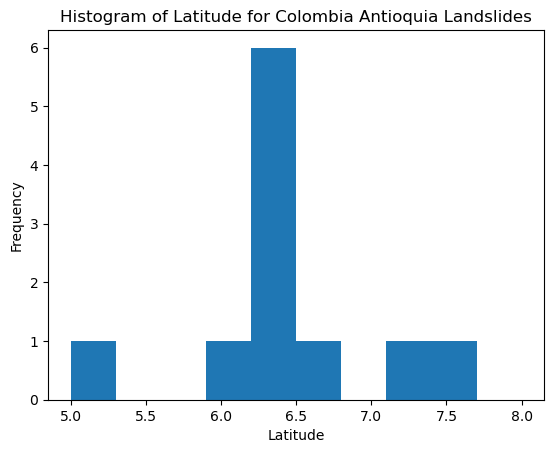

In [100]:
print(df_Colombia_Antioquia['latitude'].value_counts())
print(df_Colombia_Antioquia['latitude'].min())
print(df_Colombia_Antioquia['latitude'].max())
plt.hist(df_Colombia_Antioquia['latitude'], bins=10, range=(5, 8))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for Colombia Antioquia Landslides')
plt.show()

In [ ]:
# Reducimos el rango de latitud a (6, 7.75)
df_Colombia_Antioquia_filtered = df_Colombia_Antioquia[(df_Colombia_Antioquia['latitude'] >= 6) & (df_Colombia_Antioquia['latitude'] <= 7.75)]
print(df_Colombia_Antioquia_filtered.shape)

(10, 31)


In [103]:
# Ahora chequeamos la longitud minima y maxima de este nuevo dataset filtrado y construimos un histograma de longitudes para este nuevo dataset filtrado
print(df_Colombia_Antioquia_filtered['longitude'].min())
print(df_Colombia_Antioquia_filtered['longitude'].max())



-75.9917
-74.9411


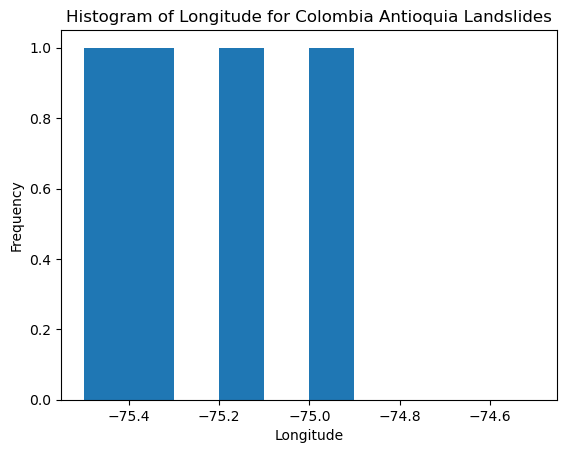

In [105]:
# Y construimos un histograma de longitudes para este nuevo dataset filtrado
plt.hist(df_Colombia_Antioquia_filtered['longitude'], bins=10, range=(-75.5, -74.5))
plt.xlabel('Longitude') 
plt.ylabel('Frequency')
plt.title('Histogram of Longitude for Colombia Antioquia Landslides')
plt.show()

In [106]:
# Vale, ahora veamos esquina inferior izquierda: menor latitud, y de esos menor longitud. Y la esquina superior derecha: mayor latitud, y de esos mayor longitud.
min_lat = df_Colombia_Antioquia_filtered['latitude'].min()
min_lon = df_Colombia_Antioquia_filtered[df_Colombia_Antioquia_filtered['latitude'] == min_lat]['longitude'].min()
max_lat = df_Colombia_Antioquia_filtered['latitude'].max()
max_lon = df_Colombia_Antioquia_filtered[df_Colombia_Antioquia_filtered['latitude'] == max_lat]['longitude'].max()
print(f"Esquina inferior izquierda: lat={min_lat}, lon={min_lon}")
print(f"Esquina superior derecha: lat={max_lat}, lon={max_lon}")

Esquina inferior izquierda: lat=6.08, lon=-75.639
Esquina superior derecha: lat=7.6167, lon=-75.3337


COMPROBACIÓN DE OTRAS REGIONES PARA CHINA

In [10]:
# Vectorizamos los documentos de test usando TF-IDF
# Crea el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer (
    stop_words=None, 
    ngram_range= (1,1),
    analyzer='word',
    max_df=0.5,
    min_df=1,
    max_features= None
)


X_train_tfidf_full = tfidf_vectorizer.fit_transform(raw_documents=train_documentos_procesados_c)

# Entrenamos el clasificador NB usando los datos vectorizados por TF-IDF
clf_tfidf_full = MultinomialNB (
    alpha= 1.0,
    force_alpha= True,
    fit_prior= True, 
    class_prior= None,
)
clf_tfidf_full.fit(X_train_tfidf_full, df_china['location_description'])

# Mostramos algunos aspectos del modelo entrenado.

print("Clases del modelo NB por TF-IDF entrenado:", clf_tfidf_full.classes_)

# Muestra top frecuencias del modelo TF-IDF
feature_counts = np.asarray(X_train_tfidf_full.sum(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_freq = list(zip(feature_names, feature_counts)) # Lista de tuplas (palabra, frecuencia)
feature_freq.sort(key=lambda x: x[1], reverse=True)
print("Top 10 palabras más frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[:10]:
    print(f"{word}: {freq}")
print("Top 10 palabras menos frecuentes (modelo TF-IDF)")
print("------------------------------")
for word, freq in feature_freq[-10:]:   
    print(f"{word}: {freq}")



Clases del modelo NB por TF-IDF entrenado: [' Maojiazu(?) subvillage, Guanshan village(?), near Yunshan(Dayunshan) National Forest Park, Zhanqiao township, Linxiang district, Yueyang city, Hunan'
 '2 km from the Zham Port, on China-Nepal Highway, Tibet'
 '4 provincial-level regions (Chongqing, Sichuan, Guizhou, and Yunnan); also in Bingzhonglou county'
 'A highway in Yunnan Province, Fugong County, Nujiang Lisu Autonomous Prefecture'
 'Anhui' 'Ankang' 'Ankang City' 'Ankang city, Shaanzi Province'
 'Badong county, Hubei province'
 'Baihe County of Ankang City, Shaanxi Province'
 'Baijian Town, Jixian county' 'Baimu River in Ya’an City'
 'Baliu\xa0Township, Mojiang Hani Autonomous County'
 'Banpo Village, Leibo County, Sichuan Province ('
 "Bao'an District, Shenzhen, Guangdong Province" 'Beichuan County'
 "Beijing-Kunming expressway, Ya'an, Sichuan province" 'Bijie, Guizhou'
 'Bijie, Guizhou Province' 'Bobai,Guangxi Zhuang'
 'Bomi County, eastern Tibet, of the Sichuan-Tibet highway'
 "Bo

YUNNAN

(38, 31)
latitude
27.5862    2
23.8900    1
27.4489    1
27.3200    1
27.4761    1
27.8541    1
28.0436    1
28.2654    1
27.8189    1
27.1780    1
25.8497    1
24.9000    1
25.0400    1
27.8878    1
24.9936    1
27.3340    1
27.1746    1
26.6432    1
34.0982    1
26.8844    1
25.0967    1
25.1657    1
25.9365    1
25.6167    1
24.7032    1
24.4267    1
27.8694    1
26.6842    1
27.2310    1
26.6455    1
27.6391    1
27.3300    1
22.7559    1
28.2000    1
27.3440    1
27.7783    1
23.9000    1
Name: count, dtype: int64
22.7559
34.0982


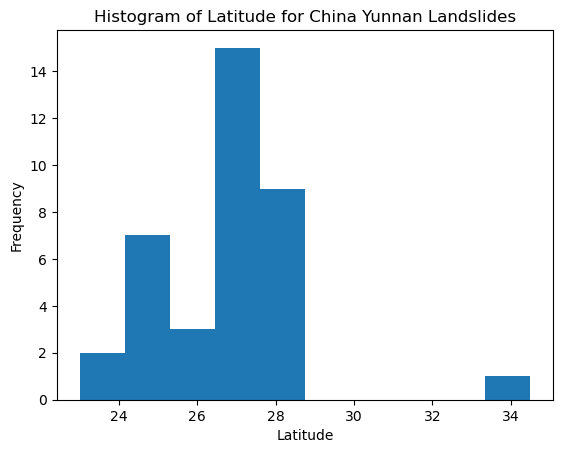

In [11]:
df_China_yunnan = df_china[df_china['location_description'].str.contains('Yunnan', case=False, na=False)]
print(df_China_yunnan.shape)
print(df_China_yunnan['latitude'].value_counts())
print(df_China_yunnan['latitude'].min())
print(df_China_yunnan['latitude'].max())
plt.hist(df_China_yunnan['latitude'], bins=10, range=(23, 34.5))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for China Yunnan Landslides')
plt.show()

(30, 31)
98.4579
104.8805


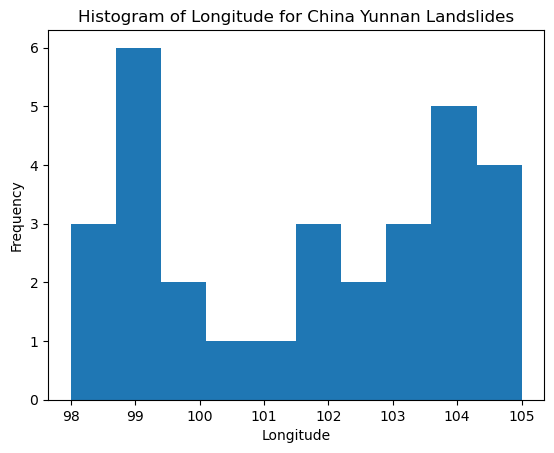

In [14]:
# Vamos a acotar el rango de latitud a (24.5, 28)
df_China_yunnan_acotado = df_China_yunnan[(df_China_yunnan['latitude'] >= 24.5) & (df_China_yunnan['latitude'] <= 28)]
print(df_China_yunnan_acotado.shape)
# Ahora vemos los limites de longitud de este nuevo dataset filtrado
print(df_China_yunnan_acotado['longitude'].min())
print(df_China_yunnan_acotado['longitude'].max())
# Y construimos un histograma de longitudes para este nuevo dataset filtrado
plt.hist(df_China_yunnan_acotado['longitude'], bins=10, range=(98, 105))
plt.xlabel('Longitude') 
plt.ylabel('Frequency')
plt.title('Histogram of Longitude for China Yunnan Landslides')
plt.show()

Se puede comprobar facilmente, la dispersión de los deslizamientos en dicha región. Mucha mayor que en Sichuan. Vamos con otra región.

GUIZHOU


(26, 31)
latitude
26.6579    1
28.5919    1
26.6582    1
31.2922    1
27.0988    1
26.5984    1
27.7218    1
28.1336    1
25.1784    1
27.1370    1
24.9920    1
27.4761    1
27.1761    1
27.4010    1
27.2482    1
27.2284    1
25.9612    1
25.9548    1
26.6597    1
27.1240    1
26.9160    1
26.9226    1
26.6537    1
22.7600    1
28.1581    1
26.6429    1
Name: count, dtype: int64
22.76
31.2922


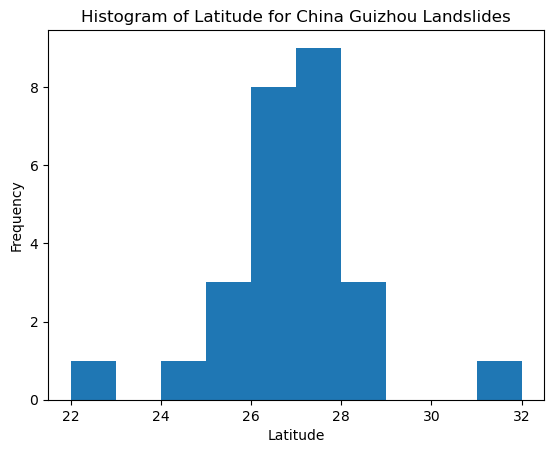

In [16]:
df_China_guizhou = df_china[df_china['location_description'].str.contains('Guizhou', case=False, na=False)]
print(df_China_guizhou.shape)
print(df_China_guizhou['latitude'].value_counts())
print(df_China_guizhou['latitude'].min())
print(df_China_guizhou['latitude'].max())
plt.hist(df_China_guizhou['latitude'], bins=10, range=(22, 32))
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Latitude for China Guizhou Landslides')
plt.show()

(22, 31)
103.763
111.8963


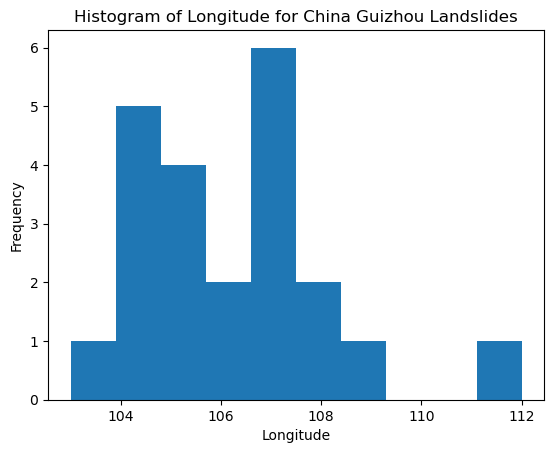

In [18]:
# Acotamos el rango de latitud a (25, 28.5)
df_China_guizhou_acotado = df_China_guizhou[(df_China_guizhou['latitude'] >= 25) & (df_China_guizhou['latitude'] <= 28.5)]
print(df_China_guizhou_acotado.shape)
# Vemos los límites de longitud del nuevo dataset filtrado
print(df_China_guizhou_acotado['longitude'].min())
print(df_China_guizhou_acotado['longitude'].max())
# Histograma de longitudes para el nuevo dataset filtrado
plt.hist(df_China_guizhou_acotado['longitude'], bins=10, range=(103, 112))
plt.xlabel('Longitude') 
plt.ylabel('Frequency')
plt.title('Histogram of Longitude for China Guizhou Landslides')
plt.show()

Nada, no es suficiente para competir contra Sichuan. 